# BrushCue Example: Cyberpunk Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/cyberpunk_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/cyberpunk-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


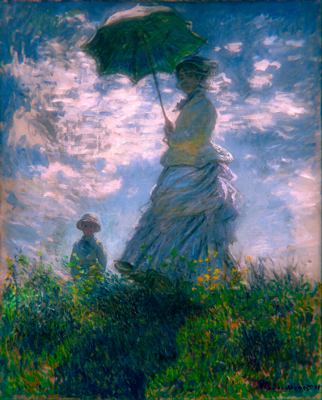

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 1.0
remapped = input_image.color_transformer_shader(
    "let c = length(input.yz);\nlet h = atan2(input.z, input.y);\nlet colorful = smoothstep(0.01, 0.05, c);\nlet vivid = mix(0.45, 1.0, smoothstep(0.06, 0.16, c));\nlet warm = band(h, 0.65, 1.0) * colorful * vivid * amount;\nlet yellow = band(h, 1.85, 0.6) * colorful * amount;\nlet green = band(h, 2.6, 1.0) * colorful * amount;\nlet h2 = h - 0.8 * warm - 0.35 * yellow + 0.85 * green;\nlet c2 = c * (1.0 + 0.25 * warm + 0.2 * yellow + 0.15 * green);\nvar l = pow(max(input.x, 0.0), 1.0 + 0.45 * amount);\nlet s_curve = l * l * (3.0 - 2.0 * l);\nl = mix(l, s_curve, 0.35 * amount);\nlet lo = 1.0 - smoothstep(0.15, 0.6, l);\nlet hi = smoothstep(0.45, 0.9, l);\nlet a = c2 * cos(h2) + (-0.06 * lo + 0.05 * hi) * amount;\nlet b = c2 * sin(h2) + (-0.035 * lo - 0.035 * hi) * amount;\nreturn vec4<f32>(l, a, b, input.w);",
    "fn band(h: f32, center: f32, width: f32) -> f32 {\n  let d = abs(atan2(sin(h - center), cos(h - center)));\n  return 1.0 - smoothstep(width * 0.5, width, d);\n}",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)
contrasted = remapped.saturation_adjust((1.0 + (0.2 * strength)))
bounds = input_image.bounds()
glowed = contrasted.bloom(0.62, (bounds.width() * 0.015), (0.6 * strength))
aberration_px = (bounds.width() * 0.004) * strength
aberrated = glowed.spacial_effect_shader(
    "let min_position = image_bounds.xy + vec2<f32>(0.5);\nlet max_position = image_bounds.zw - vec2<f32>(0.5);\nlet uv = (position - image_bounds.xy) / (image_bounds.zw - image_bounds.xy);\nlet d = uv - vec2<f32>(0.5);\nlet offset = d * 2.0 * dot(d, d) * 2.0 * aberration_px;\nlet r = sample(clamp(position + offset, min_position, max_position)).r;\nlet center = sample(position);\nlet b = sample(clamp(position - offset, min_position, max_position)).b;\nreturn vec4<f32>(r, center.g, b, center.a);",
    "",
    (aberration_px + 1.0),
    bc.Dictionary.create()
    .add("aberration_px", aberration_px)
    .add("image_bounds", bounds),
    bc.ColorRepresentation.srgb(),
)
graph = aberrated.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
